In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
np.random.seed(42)

n = 500
locations = ['Downtown', 'Suburb', 'Rural', 'Uptown']
location_premium = {'Downtown': 50000, 'Suburb': 20000, 'Rural': -15000, 'Uptown': 35000}

size_sqft = np.random.normal(1800, 600, n).clip(500, 4500)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age_years = np.random.randint(0, 50, n)
location = np.random.choice(locations, n)

base_price = 50000
price = (
    base_price
    + size_sqft * 120
    + bedrooms * 15000
    + bathrooms * 10000
    - age_years * 800
    + np.array([location_premium[loc] for loc in location])
    + np.random.normal(0, 20000, n)
)
price = price.clip(50000, None)

df = pd.DataFrame({
    'Size_sqft': size_sqft.round(0),
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age_years': age_years,
    'Location': location,
    'Price': price.round(0)
})

df.to_csv('house_data.csv', index=False)
df = pd.read_csv('house_data.csv')
df.head()

,Size_sqft,Bedrooms,Bathrooms,Age_years,Location,Price
0,2098.0,2,2,40,Uptown,336673.0
1,1717.0,2,2,0,Downtown,349983.0
2,2189.0,3,1,4,Rural,331881.0
3,2714.0,3,3,19,Uptown,486108.0
4,1660.0,5,3,7,Downtown,386888.0


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Size_sqft  500 non-null    float64
 1   Bedrooms   500 non-null    int64  
 2   Bathrooms  500 non-null    int64  
 3   Age_years  500 non-null    int64  
 4   Location   500 non-null    object 
 5   Price      500 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 23.6+ KB
None

Missing values:
 Size_sqft    0
Bedrooms     0
Bathrooms    0
Age_years    0
Location     0
Price        0
dtype: int64


,Size_sqft,Bedrooms,Bathrooms,Age_years,Price
count,500.00000,500.000000,500.000000,500.00000,500.000000
mean,1806.08400,2.966000,1.980000,24.23200,335228.302000
std,583.44936,1.422988,0.808026,14.88103,81354.440912
min,500.00000,1.000000,1.000000,0.00000,123312.000000
25%,1379.75000,2.000000,1.000000,11.00000,279399.500000
50%,1808.00000,3.000000,2.000000,24.00000,332849.500000
75%,2181.75000,4.000000,3.000000,37.00000,390671.250000
max,4112.00000,5.000000,3.000000,49.00000,651243.000000


In [4]:
# One-hot encode the categorical Location column
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [6]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Model trained successfully.")

Model trained successfully.


In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score: {r2:.4f}")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_}).sort_values(
    by='Coefficient', ascending=False
)
coef_df

Mean Squared Error (MSE): 308527875.41
Root Mean Squared Error (RMSE): 17564.96
Mean Absolute Error (MAE): 14442.87
R-squared Score: 0.9514


,Feature,Coefficient
0,Size_sqft,69942.790372
1,Bedrooms,20400.734046
2,Bathrooms,6879.202545
6,Location_Uptown,-5480.546764
3,Age_years,-12501.483982
5,Location_Suburb,-12699.555331
4,Location_Rural,-29326.653974


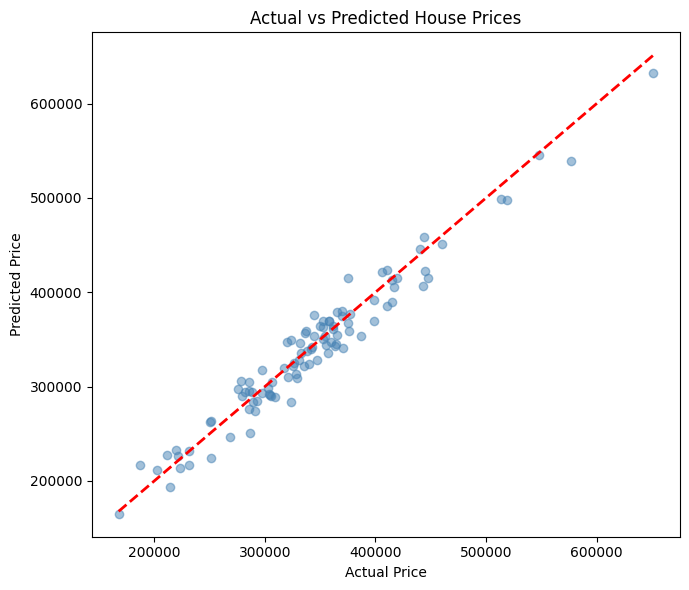

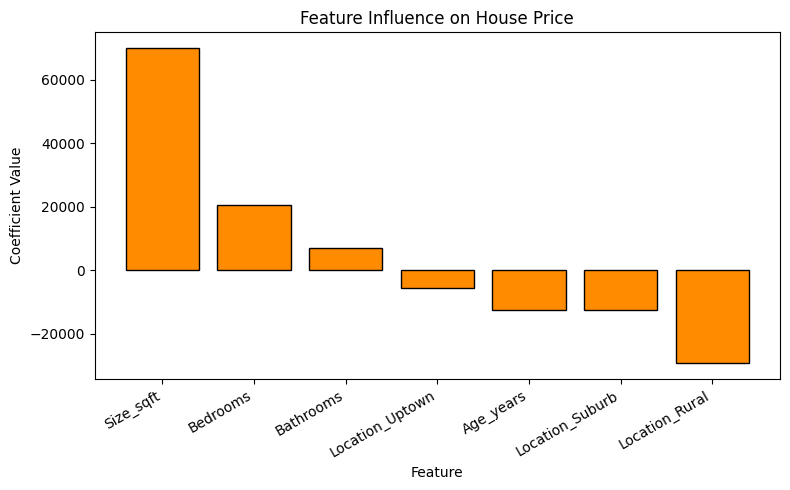

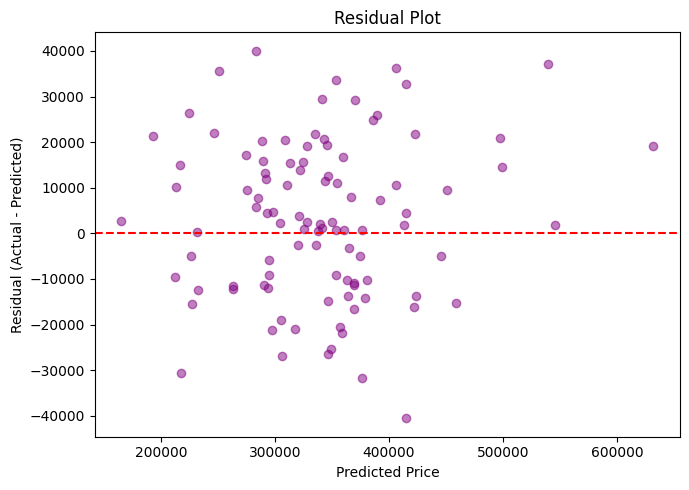

In [8]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()

# Feature coefficients
plt.figure(figsize=(8, 5))
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color='darkorange', edgecolor='black')
plt.title('Feature Influence on House Price')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

In [10]:
new_house = pd.DataFrame({
    'Size_sqft': [2000],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'Age_years': [5],
    'Location_Rural': [0],
    'Location_Suburb': [0],
    'Location_Uptown': [1]
})

new_house = new_house[X.columns]  # match column order
new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print(f"Predicted price for a 2000 sqft, 3-bed, 2-bath, 5-year-old house in Uptown: {predicted_price[0]:.2f}")

Predicted price for a 2000 sqft, 3-bed, 2-bath, 5-year-old house in Uptown: 389397.14
